# Analysis of the Gun Violence Dataset

# Predictive Modeling of Incident Severity

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----

In this notebook, we build models to predict the severity of gun violence incidents.

We frame the problem in the following ways:
1. **Has Casualties vs No Casualties (Classification):** Binary prediciton of `n_killed + n_injured > 0`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)

np.random.seed(42)

## 1. Loading Data & Creating Targets

In [383]:
df = pd.read_parquet("../data/incidents.parquet")

# Total causalties
df["target_total_casualties"] = df["n_killed"] + df["n_injured"]

# Lethality ratio (only for incidents with at least 1 casualty)
df["target_lethality_ratio"] = np.where(
    df["target_total_casualties"] > 0,
    df["n_killed"] / df["target_total_casualties"],
    np.nan,
)

In [384]:
# Merge race data
df_race = pd.read_csv("../data/state_race_2015.csv")
race_cols = [
    "pct_white",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "pct_native",
    "pct_mixed",
]
df = df.merge(df_race, on="state", how="left")
df[["state"] + race_cols].head()

,state,pct_white,pct_black,pct_hispanic,pct_asian,pct_native,pct_mixed
0,Pennsylvania,76.0,10.0,8.0,4.0,0.0,2.0
1,California,36.0,5.0,40.0,15.0,0.0,3.0
2,Ohio,79.0,12.0,4.0,2.0,0.0,3.0
3,Colorado,68.0,4.0,22.0,3.0,1.0,3.0
4,North Carolina,63.0,21.0,10.0,3.0,1.0,3.0


In [385]:
df[race_cols].isna().sum()

pct_white       0
pct_black       0
pct_hispanic    0
pct_asian       0
pct_native      0
pct_mixed       0
dtype: int64

In [386]:
# Merge unemployment data
df_unemployment = pd.read_csv("../data/state_unemployment_2015.csv")
df = df.merge(df_unemployment, on="state", how="left")
df[["state", "unemployment"]].head()

,state,unemployment
0,Pennsylvania,5.2
1,California,6.2
2,Ohio,4.9
3,Colorado,3.9
4,North Carolina,5.9


In [387]:
df["unemployment"].isna().sum()

np.int64(0)

## 2. Feature Selection & Preparation

In [388]:
# Date features
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

# Contextual characteristics to extract
contextual_characteristics = [
    "Drug involvement",
    "Drive-by (car to street, car to car)",
    "Institution/Group/Business",
    "Domestic Violence",
    "Home Invasion",
    "Gang involvement",
    "Bar/club incident - in or around establishment",
    "School Incident",
    "Car-jacking",
    "Possession of gun by felon or prohibited person",
]

df["incident_characteristics"] = df["incident_characteristics"].fillna("")
char_features = []

for char in contextual_characteristics:
    # Create simple binary flags
    feature_name = (
        f"char_{char.split(' ')[0].lower().replace('/', '_').replace('-', '_')}"
    )
    df[feature_name] = (
        df["incident_characteristics"].str.contains(char, regex=False).astype(int)
    )
    char_features.append(feature_name)

print("Created characteristic features:", char_features)

Created characteristic features: ['char_drug', 'char_drive_by', 'char_institution_group_business', 'char_domestic', 'char_home', 'char_gang', 'char_bar_club', 'char_school', 'char_car_jacking', 'char_possession']


In [389]:
features = [
    "state",
    "month",
    "day_of_week",
    "n_guns_involved",
    "latitude",
    "longitude",
    #'unemployment'
]
# ] + race_cols
# ] + char_features

X_raw = df[features].copy()
# X_raw["state"] = X_raw["state"].fillna("unknown")
# X_raw["n_guns_involved"] = X_raw["n_guns_involved"].fillna(-1)
# X_raw["latitude"] = X_raw["latitude"].fillna(0)
# X_raw["longitude"] = X_raw["longitude"].fillna(0)

X = pd.get_dummies(X_raw, columns=["state", "month", "day_of_week"], drop_first=True)

## 3. Modeling

### 3.1 Casualties vs. No Casualties (Binary Classification)

We can frame this as predicting whether an incident will have **any casualties at all** (Killed + Injured > 0) versus **no casualties** (property damage, shots fired, but no one hit). This is a more balanced binary problem compare to severity tier classification which is difficult due to class imbalance.

In [390]:
# Binary target: 1 if any casualties, 0 otherwise
df["target_has_casualties"] = (df["target_total_casualties"] > 0).astype(int)
df["target_has_casualties"].value_counts(normalize=True)

target_has_casualties
1    0.594091
0    0.405909
Name: proportion, dtype: float64

In [391]:
y_bin = df["target_has_casualties"]
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

### 3.1a Random Forest

In [392]:
rf_bin = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    oob_score=True,
)
rf_bin.fit(X_train_bin, y_train_bin)
print(f"Random Forest OOB Score (Accuracy): {rf_bin.oob_score_:.4f}")

Random Forest OOB Score (Accuracy): 0.6534


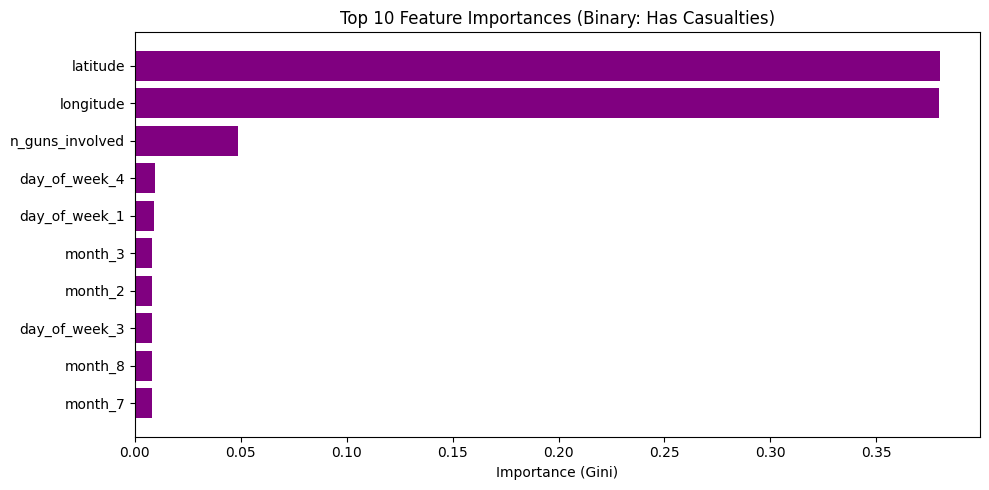

In [393]:
importances_bin = rf_bin.feature_importances_
top_idx_bin = np.argsort(importances_bin)[-10:]

plt.figure(figsize=(10, 5))
plt.barh(X.columns[top_idx_bin], importances_bin[top_idx_bin], color="purple")
plt.title("Top 10 Feature Importances (Binary: Has Casualties)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

In [394]:
y_pred_bin = rf_bin.predict(X_test_bin)
print("Classification Report (Random Forest):")
print(
    classification_report(
        y_test_bin, y_pred_bin, target_names=["No Casualties (0)", "Has Casualties (1)"]
    )
)

Classification Report (Random Forest):
                    precision    recall  f1-score   support

 No Casualties (0)       0.58      0.55      0.56     19458
Has Casualties (1)       0.70      0.73      0.72     28478

          accuracy                           0.66     47936
         macro avg       0.64      0.64      0.64     47936
      weighted avg       0.65      0.66      0.65     47936



### 3.1b Histogram-based Gradient Boosting

In [395]:
hgb_bin = HistGradientBoostingClassifier(
    random_state=42, early_stopping=True, validation_fraction=0.1
)
hgb_bin.fit(X_train_bin, y_train_bin)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dt

In [396]:
y_pred_bin = hgb_bin.predict(X_test_bin)
print("Classification Report (HistGradientBoosting):")
print(
    classification_report(
        y_test_bin, y_pred_bin, target_names=["No Casualties (0)", "Has Casualties (1)"]
    )
)

Classification Report (HistGradientBoosting):
                    precision    recall  f1-score   support

 No Casualties (0)       0.67      0.41      0.51     19458
Has Casualties (1)       0.68      0.86      0.76     28478

          accuracy                           0.68     47936
         macro avg       0.68      0.64      0.64     47936
      weighted avg       0.68      0.68      0.66     47936

